In [1]:
import pandas as pd
from sklearn.metrics import matthews_corrcoef, f1_score, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.calibration import calibration_curve
import numpy as np
from scipy.stats import pearsonr
import os
import matplotlib.pyplot as plt

from collections import defaultdict

Observation:
For GPT4o;
We get about a 100 results like *"Sorry, I cannot determine the cardiovascular risk based on the provided text"*

In [40]:
path = r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\G_Output\2_Data\parquet\labeled_texts_gpt-4o.jsonl'
with open(path, 'r', encoding='latin1') as fr:
    llm_res =  pd.read_json(fr, lines=True, nrows=3482)
    llm_res = llm_res.assign(inferred_label=llm_res.inferred_label.str.replace(r'^.*sorry, i cannot determine.*', 'uncertain', regex=True, case=False))
    llm_res = llm_res.assign(inferred_label=llm_res.inferred_label.str.replace(r'^.*I am sorry, i cannot determine.*', 'uncertain', regex=True, case=False))
    llm_res = llm_res.assign(inferred_label=llm_res.inferred_label.str.replace(r'^.*I\'m sorry, i cannot determine.*', 'uncertain', regex=True, case=False))
    llm_res = llm_res.assign(inferred_label=llm_res.inferred_label.str.replace(r'^.*I\'m sorry, i can only.*', 'uncertain', regex=True, case=False))
    llm_res = llm_res.assign(inferred_label=llm_res.inferred_label.str.replace(r'^.*sorry, i can only.*', 'uncertain', regex=True, case=False))
    llm_res = llm_res.assign(inferred_label=llm_res.inferred_label.str.replace(r'^.*I cannot determine.*', 'uncertain', regex=True, case=False))
    llm_res.loc[llm_res.inferred_label.str.startswith(('Yes', 'yes')), 'inferred_label'] = 'yes'

    llm_res_original = llm_res.copy()

print(llm_res_original.inferred_label.value_counts())

lab_map = {
    'no': 0,
    'nee': 0,
    'yes': 1,
    'ja': 1,
    'no.': 0,
    'nee.': 0,
    'yes.': 1,
    'ja.': 1,
    'uncertain': 0.5
}
llm_res = llm_res.assign(inferred_label=
                         llm_res.inferred_label.str.lower().map(lab_map, na_action='ignore'))
llm_res = llm_res.assign(proba=llm_res.logprob.apply(lambda x: np.exp(x)))
llm_res = llm_res[['id', 'inferred_label', 'coded_label', 'proba']]
llm_res = llm_res.rename(columns={'coded_label':'label'})
llm_res['id'] = llm_res['id'].astype(int)
llm_res.dropna(inplace=True)
llm_res = llm_res.assign(proba=np.abs(np.abs(llm_res.inferred_label-1)-llm_res.proba))

inferred_label
yes    2986
No      496
Name: count, dtype: int64


In [41]:
llm_res.inferred_label.value_counts().sum(), llm_res.shape, llm_res_original.shape

(np.int64(3482), (3482, 4), (3482, 11))

In [42]:
# coded_res = pd.read_parquet(r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\G_Output\2_Data\parquet\df_consults_medication.parquet')
# coded_res = coded_res[['studyId_0831', 'label']]
# coded_res = coded_res.assign(studyId_0831=coded_res['studyId_0831'].astype(int))

In [43]:
# RES = llm_res.merge(coded_res, left_on='id', right_on='studyId_0831', how='inner', suffixes=('_llm', '_coded'))
# RES = RES.drop('studyId_0831', axis=1)
RES = llm_res

In [44]:
# coded_res.label.mean()

In [45]:
# add reference scores
# set random label
np.random.seed(42)
scores_random_list = []
num_rounds = 100
for _ in range(num_rounds):
    random_label = np.random.choice([0,1], size=len(RES), p=[0.2,0.8])
    scores_random_list.append({
        'MCC': matthews_corrcoef(RES['label'], random_label),
        'Accuracy': accuracy_score(RES['label'], random_label),
        'Precision': precision_score(RES['label'], random_label),
        'Recall': recall_score(RES['label'], random_label),
        'F1':f1_score(RES['label'], random_label),
        'ROC-AUC': np.nan,
        'Balanced Accuracy': balanced_accuracy_score(RES['label'], random_label),
        'Pearson r': pearsonr(RES['label'], random_label)[0],
    })

RES = RES.assign(random_label=np.random.choice([0,1], size=len(RES), p=[0.8,0.2]))

# set majority label
majority_label = RES['label'].mode()[0]
RES = RES.assign(majority_label=majority_label)

SCORES_majority = {
    'MCC': matthews_corrcoef(RES['label'], RES['majority_label']),
    'Accuracy': accuracy_score(RES['label'], RES['majority_label']),
    'Precision': precision_score(RES['label'], RES['majority_label']),
    'Recall': recall_score(RES['label'], RES['majority_label']),
    'F1':f1_score(RES['label'], RES['majority_label']),
    'ROC-AUC': np.nan,
    'Balanced Accuracy': balanced_accuracy_score(RES['label'], RES['majority_label']),
    'Pearson r': pearsonr(RES['label'], RES['majority_label'])[0],
} 


c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\odin-1CyeSJpB-py3.12\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bes3\AppData\Local\Temp\ipykernel_30040\3096557808.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'Pearson r': pearsonr(RES['label'], RES['majority_label'])[0],


In [46]:
RES_doubt = RES[RES['inferred_label'] == 0.5].copy()
RES = RES[RES['inferred_label'] != 0.5].copy()

In [47]:
SCORES = {
    'MCC': matthews_corrcoef(RES['label'], RES['inferred_label']),
    'Accuracy': accuracy_score(RES['label'], RES['inferred_label']),
    'Precision': precision_score(RES['label'], RES['inferred_label']),
    'Recall': recall_score(RES['label'], RES['inferred_label']),
    'F1':f1_score(RES['label'], RES['inferred_label']),
    'ROC-AUC': roc_auc_score(RES['label'], RES['proba']),
    'Balanced Accuracy': balanced_accuracy_score(RES['label'], RES['inferred_label']),
    'Pearson r': pearsonr(RES['label'
    ], RES['inferred_label'])[0],
}

<Axes: >

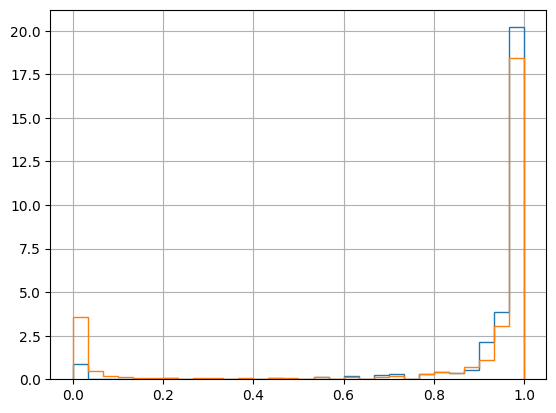

In [48]:
 RES.query('label==1')['proba'].hist(bins=30, histtype='step', density=True)
 RES.query('label==0')['proba'].hist(bins=30, histtype='step', density=True)

Text(0.5, 1.0, 'Calibration Curve')

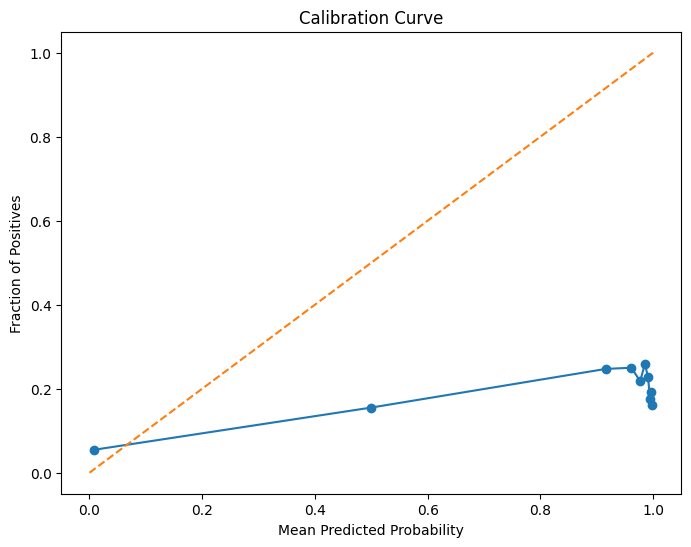

In [49]:
calibration_curve_data = calibration_curve(RES['label'],
                                           RES['proba'],
                                           n_bins=10,
                                           strategy='quantile')
plt.figure(figsize=(8, 6))
plt.plot(calibration_curve_data[1], calibration_curve_data[0], marker='o', label='LLM Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')

In [50]:
SCORES

{'MCC': np.float64(0.1395810748366276),
 'Accuracy': 0.31964388282596207,
 'Precision': np.float64(0.21634293369055593),
 'Recall': np.float64(0.957037037037037),
 'F1': np.float64(0.35290904124556133),
 'ROC-AUC': np.float64(0.5289801950151078),
 'Balanced Accuracy': np.float64(0.5617034134241117),
 'Pearson r': np.float64(0.1395810748366276)}

In [38]:
scores_agg = defaultdict(list)
for score_dict in scores_random_list:
    for k, v in score_dict.items():
        scores_agg[k].append(v)

In [39]:
for k, v in scores_agg.items():
    print(f'Random {k}: Mean={np.mean(v):.4f}, Std={np.std(v):.4f}')

Random MCC: Mean=-0.0013, Std=0.0168
Random Accuracy: Mean=0.3156, Std=0.0067
Random Precision: Mean=0.1936, Std=0.0033
Random Recall: Mean=0.7994, Std=0.0147
Random F1: Mean=0.3117, Std=0.0053
Random ROC-AUC: Mean=nan, Std=nan
Random Balanced Accuracy: Mean=0.4994, Std=0.0085
Random Pearson r: Mean=-0.0013, Std=0.0168


In [15]:
SCORES_majority

{'MCC': 0.0,
 'Accuracy': 0.8061458931648477,
 'Precision': np.float64(0.0),
 'Recall': np.float64(0.0),
 'F1': np.float64(0.0),
 'ROC-AUC': nan,
 'Balanced Accuracy': np.float64(0.5),
 'Pearson r': np.float64(nan)}